Experiment -  (Autoencoders)

---

Name : Shruti Hore

PRN : 24070126172

---

About dataset :
- The Digits dataset contains images of handwritten digits (0–9).

- Each image is 8×8 pixels, resulting in 64 numerical features per sample.

- It has 1,797 samples with 10 target classes (digits 0–9).

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ModuleNotFoundError: No module named 'torchvision'

In [ ]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=128, shuffle=False)


In [ ]:
# 3. Define Autoencoder Model
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        # Encoder: 784 -> 32
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32)  # Latent space
        )

        # Decoder: 32 -> 784
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 28*28),
            nn.Sigmoid()  # Output between 0 and 1
        )

    def forward(self, x):
        x = x.view(-1, 28*28)  # Flatten
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

model = Autoencoder().to(device)

In [ ]:
# 4. Loss and Optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
# 5. Training
num_epochs = 10
train_losses = []

for epoch in range(num_epochs):
    running_loss = 0.0

    for images, _ in train_loader:
        images = images.to(device)
        images = images.view(-1, 28*28)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, images)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.6f}")


Epoch [1/10], Loss: 0.060251
Epoch [2/10], Loss: 0.030976
Epoch [3/10], Loss: 0.024302
Epoch [4/10], Loss: 0.021398
Epoch [5/10], Loss: 0.019167
Epoch [6/10], Loss: 0.017222
Epoch [7/10], Loss: 0.015986
Epoch [8/10], Loss: 0.014867
Epoch [9/10], Loss: 0.014004
Epoch [10/10], Loss: 0.013375


In [ ]:
# 6. Evaluation (Reconstruction)
model.eval()

with torch.no_grad():
    dataiter = iter(test_loader)
    images, _ = next(dataiter)
    images = images.to(device)

    outputs = model(images)

# Move to CPU for visualization
images = images.view(-1, 28, 28).cpu()
outputs = outputs.view(-1, 28, 28).cpu()

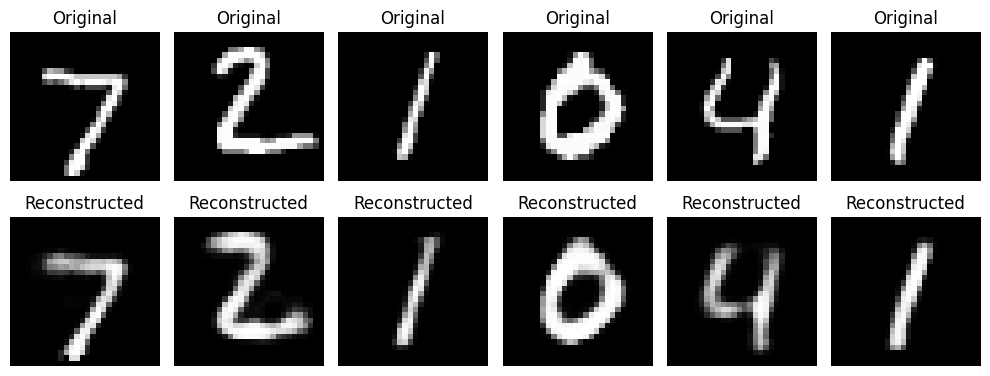

In [ ]:
n = 6  # Number of images to display
plt.figure(figsize=(10, 4))

for i in range(n):
    # Original
    ax = plt.subplot(2, n, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i+n+1)
    plt.imshow(outputs[i], cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.tight_layout()
plt.show()

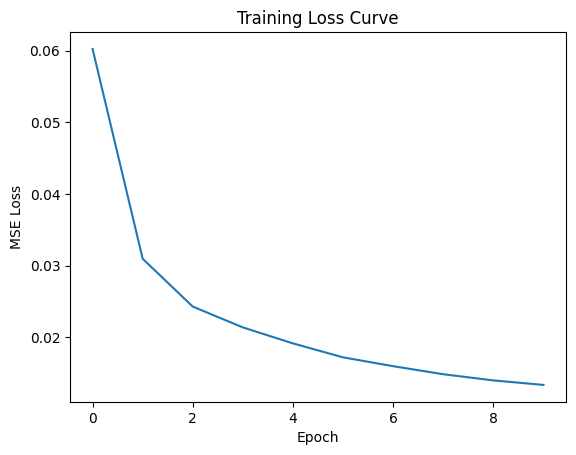

In [ ]:
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss Curve")
plt.show()

In [ ]:
test_loss = criterion(outputs.view(-1, 28*28), images.view(-1, 28*28))
print(f"Final Reconstruction Loss (MSE): {test_loss.item():.6f}")

Final Reconstruction Loss (MSE): 0.013186
